In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier

import h5py
import sys

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm


In [2]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [3]:

path = '/home/mdelafuente/'#sys.argv[2]

device = torch.device(f"cuda:2" if torch.cuda.is_available() else "cpu")

h5_file = h5py.File(
    f"{path}/ORIGINAL/elasticc_dataset_update.h5", "r"
)

abs_path = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_LP_baseline_masked_fill_0/'
path_args = glob.glob(f"{abs_path}*args*")[0]
print(path_args)
import yaml
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_LP_baseline_masked_fill_0/args.yaml


In [4]:
print('Initializing models') 
from src.layers.selfsupervised.lightcurve import LightCurveClassifier
model = LightCurveClassifier(**args) 


print('Loading checkpoints')
checkpoint_path_clip = glob.glob(
    f"{abs_path}*my_best_checkpoint*"
) 
print(checkpoint_path_clip[-1])
checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
od_atat = OrderedDict() 

for key in checkpoint_clip["state_dict"].keys(): 
        #print(key)
        if 'project' in key:
            continue
        if 'model' in key:
            od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

model.load_state_dict(od_atat,strict=True)

Initializing models
Loading checkpoints
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_LP_baseline_masked_fill_0/my_best_checkpoint-step=1580.ckpt


<All keys matched successfully>

In [5]:
seed = 0
from src.data.modules.LitData  import LitData

args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 128

pl_datal = LitData(**args['general'])
dataloader = pl_datal.val_dataloader() 
    

using set validation total of idx : 40698,                 use_lightcurves True, use_metadata False, use_features False,                     use MTA False
list_time_to_eval:  [16, 32, 64, 128, 256, 512, 1024, 2048]
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


In [6]:
target = None
preds_out = None

model.eval().to(device = 'cuda:2')  

for b1 in tqdm(dataloader):

    #print(b1.keys())
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}

    lc_emb = model(**b1)  
   
    t = b1['labels']


    preds_out = (
        np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
        if preds_out is not None
        else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
    )

    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.cpu().numpy()
    )

  5%|▍         | 15/318 [00:01<00:20, 14.85it/s]

100%|██████████| 318/318 [00:18<00:00, 16.91it/s]


In [7]:
results = preds_out
classification = classification_report(target, results, target_names=list(dict.keys()),digits = 4)
print(classification)

                precision    recall  f1-score   support

           AGN     0.3018    0.1153    0.1668      3288
           QSO     0.4200    0.3081    0.3554      3428
            EA     0.3130    0.4157    0.3571      3500
           YSO     0.2422    0.1989    0.2184      2715
          SNIa     0.1424    0.0268    0.0452      1639
       CV/Nova     0.1128    0.0724    0.0882      1617
          RRLc     0.4584    0.1777    0.2561      3439
         RSCVn     0.1432    0.0852    0.1069      2522
        Blazar     0.1106    0.0806    0.0933      1364
          SNII     0.1808    0.2531    0.2109       802
         EB/EW     0.3626    0.2825    0.3176      3635
           LPV     0.4237    0.3097    0.3579      3319
           CEP     0.2362    0.1585    0.1897      2871
         RRLab     0.3911    0.3869    0.3890      3507
Periodic-Other     0.0607    0.4205    0.1061       742
          DSCT     0.1626    0.2313    0.1910      1604
         SNIbc     0.0448    0.0383    0.0413  

AGN {'precision': 0.3017515923566879, 'recall': 0.1152676399026764, 'f1-score': 0.16681338028169015, 'support': 3288.0}
QSO {'precision': 0.4200477326968974, 'recall': 0.3080513418903151, 'f1-score': 0.35543588017502525, 'support': 3428.0}
EA {'precision': 0.3130378657487091, 'recall': 0.4157142857142857, 'f1-score': 0.35714285714285715, 'support': 3500.0}
YSO {'precision': 0.242152466367713, 'recall': 0.19889502762430938, 'f1-score': 0.21840242669362994, 'support': 2715.0}
SNIa {'precision': 0.1423948220064725, 'recall': 0.026845637583892617, 'f1-score': 0.045174537987679675, 'support': 1639.0}
CV/Nova {'precision': 0.1128254580520733, 'recall': 0.07235621521335807, 'f1-score': 0.08816880180859081, 'support': 1617.0}
RRLc {'precision': 0.45836459114778694, 'recall': 0.17766792672288456, 'f1-score': 0.2560771165129925, 'support': 3439.0}
RSCVn {'precision': 0.14323784143904064, 'recall': 0.08524980174464711, 'f1-score': 0.10688540889883172, 'support': 2522.0}
Blazar {'precision': 0.110

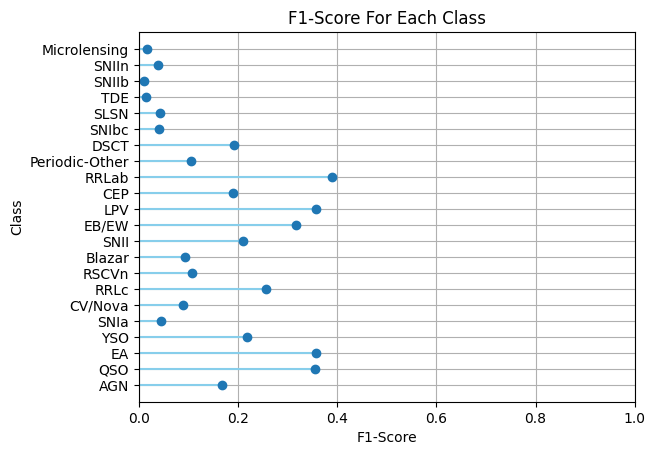

In [8]:
data_dict =  classification_report(target, results, target_names=list(dict.keys()),digits = 4, output_dict=True)
classes = data_dict.keys()
f1 = []
for key,value in data_dict.items():
    if key in dict.keys():
        print(key,value)
        f1.append(value['f1-score'])
print(f1)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
# Create a dataframe
df = pd.DataFrame({'group':dict.keys(), 'values':f1 })
 
# Reorder it based on the values
ordered_df = df#.sort_values(by='values')
my_range=range(1,len(df.index)+1)
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
plt.plot(ordered_df['values'].values, my_range, "o")
 
# Add titles and axis names
plt.yticks(my_range, ordered_df['group'])
plt.title("F1-Score For Each Class", loc='center')

plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0,1)

plt.grid('on')
# Show the plot
plt.show()

Normalized confusion matrix
group eval:
trans 0.05259227842241158
stoch 0.1844160689660136
per 0.2523719905705053


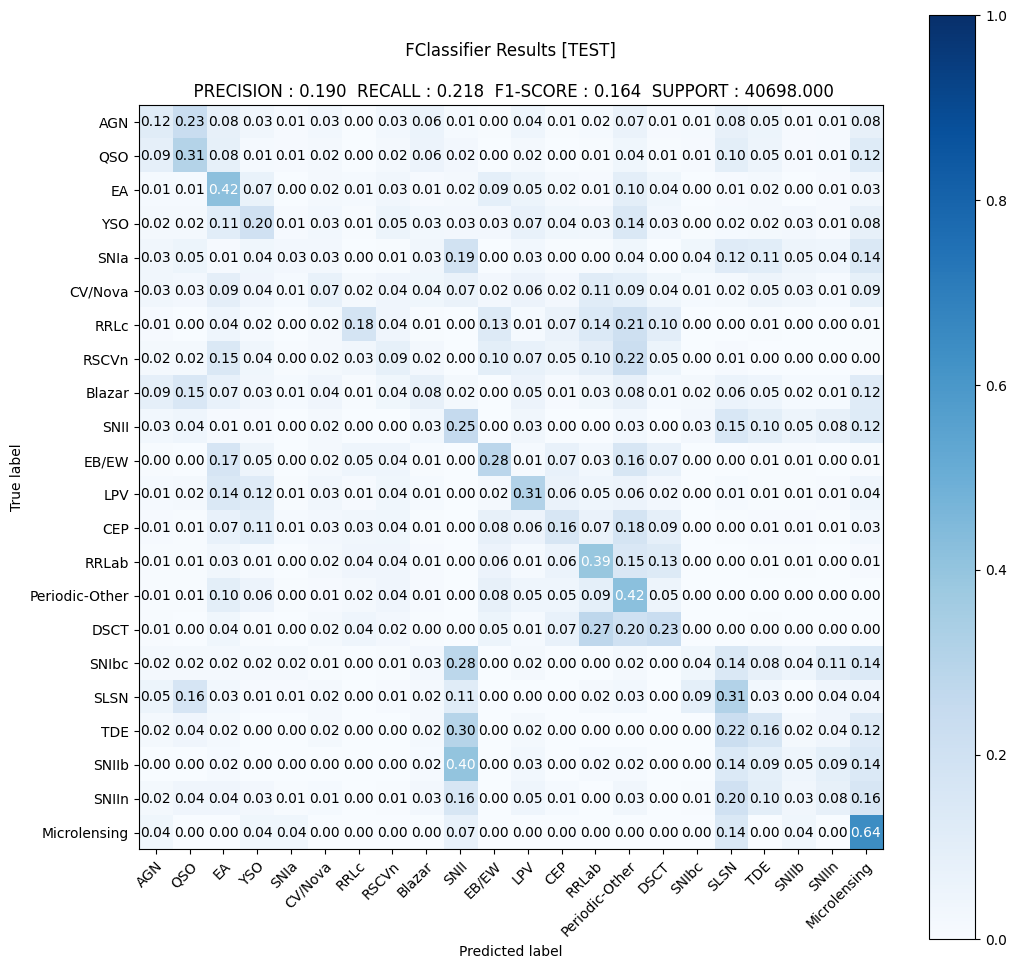

In [9]:

import matplotlib.pyplot as plt
from src.utils.plottinglib import elasticc_confusion_matrix
out_metrics_balto = classification_report(
    target, results, target_names=list(dict.keys()), output_dict=True
)["macro avg"]

template_balto = ""

for key in out_metrics_balto.keys():
    template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
fig, axes = plt.subplots(1, 1, figsize=(12, 12))
elasticc_confusion_matrix(
    y_true=np.array(target).astype(int),
    y_pred=np.array(results).astype(int),
    classes= np.array(list(dict.keys())),
    ax=axes,
    normalize=True,
    title=f" FClassifier Results [TEST] \n\n {template_balto}",
)
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict.items():
    #print(class_key)
    if class_key in dict.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [ ]:
alpha_cos = model.LC.time_encoder.time_encoders[0].


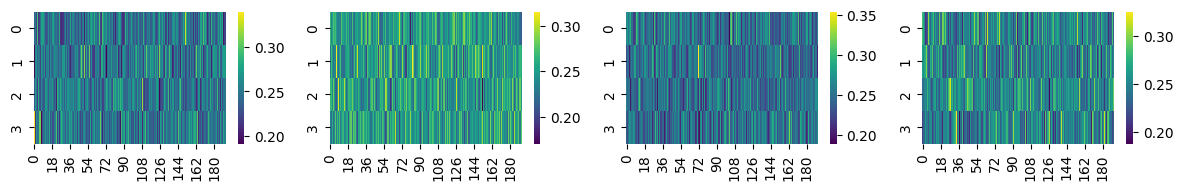

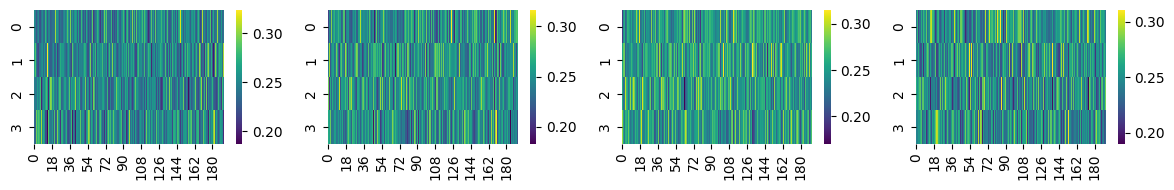

In [10]:

model.LC.time_encoder.time_encoders[0].alpha_cos.shape
import seaborn as sns
fig, ax = plt.subplots(1,4,figsize = (12,2))
alpha_cos = model.LC.time_encoder.time_encoders[0].alpha_cos.detach().cpu().numpy()
alpha_sin = model.LC.time_encoder.time_encoders[0].alpha_sin.detach().cpu().numpy()
beta_cos = model.LC.time_encoder.time_encoders[0].beta_cos.detach().cpu().numpy()
beta_sin = model.LC.time_encoder.time_encoders[0].beta_sin.detach().cpu().numpy()
alpha_cos  = np.exp(alpha_cos)/sum(np.exp(alpha_cos)) #alpha_cos / alpha_cos.max()
alpha_sin  = np.exp(alpha_sin)/sum(np.exp(alpha_sin))
beta_cos = np.exp(beta_cos)/sum(np.exp(beta_cos))
beta_sin  = np.exp(beta_sin)/sum(np.exp(beta_sin))

sns.heatmap(alpha_cos, ax = ax[0], cmap = 'viridis' )
sns.heatmap(alpha_sin, ax = ax[1], cmap = 'viridis' )
sns.heatmap(beta_cos, ax = ax[2], cmap = 'viridis' )
sns.heatmap(beta_sin, ax = ax[3], cmap = 'viridis' )

plt.tight_layout()
fig, ax = plt.subplots(1,4,figsize = (12,2))
alpha_cos = model.LC.time_encoder.time_encoders[1].alpha_cos.detach().cpu().numpy()
alpha_sin = model.LC.time_encoder.time_encoders[1].alpha_sin.detach().cpu().numpy()
beta_cos = model.LC.time_encoder.time_encoders[1].beta_cos.detach().cpu().numpy()
beta_sin = model.LC.time_encoder.time_encoders[1].beta_sin.detach().cpu().numpy()
alpha_cos  = np.exp(alpha_cos)/sum(np.exp(alpha_cos)) #alpha_cos / alpha_cos.max()
alpha_sin  = np.exp(alpha_sin)/sum(np.exp(alpha_sin))
beta_cos = np.exp(beta_cos)/sum(np.exp(beta_cos))
beta_sin  = np.exp(beta_sin)/sum(np.exp(beta_sin))

sns.heatmap(alpha_cos, ax = ax[0], cmap = 'viridis' )
sns.heatmap(alpha_sin, ax = ax[1], cmap = 'viridis' )
sns.heatmap(beta_cos, ax = ax[2], cmap = 'viridis' )
sns.heatmap(beta_sin, ax = ax[3], cmap = 'viridis' )

plt.tight_layout()
plt.show() 

plt.show() 



In [11]:
import seaborn as sns
preds_out =  []
x_mod_out = None
target = None
model = model.eval().to(device = 'cuda:2')
count = 0
maxx = 20
for b1 in tqdm(dataloader):
    with torch.no_grad():
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        t = b1['labels']
        b1 = {"x": b1['data'], "t": b1['time'], "mask": b1['mask']}
        x_mod, m_mod, _ = model.LC.embedding_light_curve(**b1)
         
        
        x_mod_out = (
            np.concatenate([x_mod_out, x_mod.detach().cpu().numpy()])
            if x_mod_out is not None
            else x_mod.cpu().detach().numpy()
        )

        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
        count +=1
        if count > maxx:
            break

  6%|▋         | 20/318 [00:03<00:52,  5.70it/s]


In [12]:
x_mod_out.shape, target.shape

((2688, 401, 192), (2688,))

In [13]:
def plot_umap(ax, umap_result, numeric_labels, num_classes, title):
    colors = ['#43aa8b', '#4d908e', '#ca5cdd', '#277da1','#f9c74f',
              '#90be6d','#f8961e', '#f94144', '#f9844a', '#90be6d', 
              '#f3722c','#277da1', '#43aa8b', '#577590', '#4d908e', 
              '#f9c74f','#90be6d', '#f94144', '#f3722c', '#f8961e', 
              '#f9844a', '#4d908e', '#ca5cdd']
    dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
    for i in range(num_classes):
        class_indices = numeric_labels == i
        markers = ['o', '^', '<', 'D', 'p',
                   'o', '^', '<', 'D', 'p', 
                   'o', '^', '<', 'D', 'p',
                   'o', '^', '<', 'D', 'p',
                   'o', '^', '<', 'D', 'p']
        ax.scatter(x=umap_result[class_indices, 0], y=umap_result[class_indices, 1],s=10, marker=markers[i],label=list(dict.keys())[i], color=colors[i],alpha = 0.75 )
        

    ax.set_facecolor('black')
    
    ax.set_title(title)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    
    plt.legend()

In [14]:
umap_in = x_mod_out.reshape(x_mod_out.shape[0],-1)
print(umap_in.shape)
import umap
umap_model = umap.UMAP(n_components=2, metric = 'euclidean')
umap_result = umap_model.fit_transform(umap_in)

(2688, 76992)


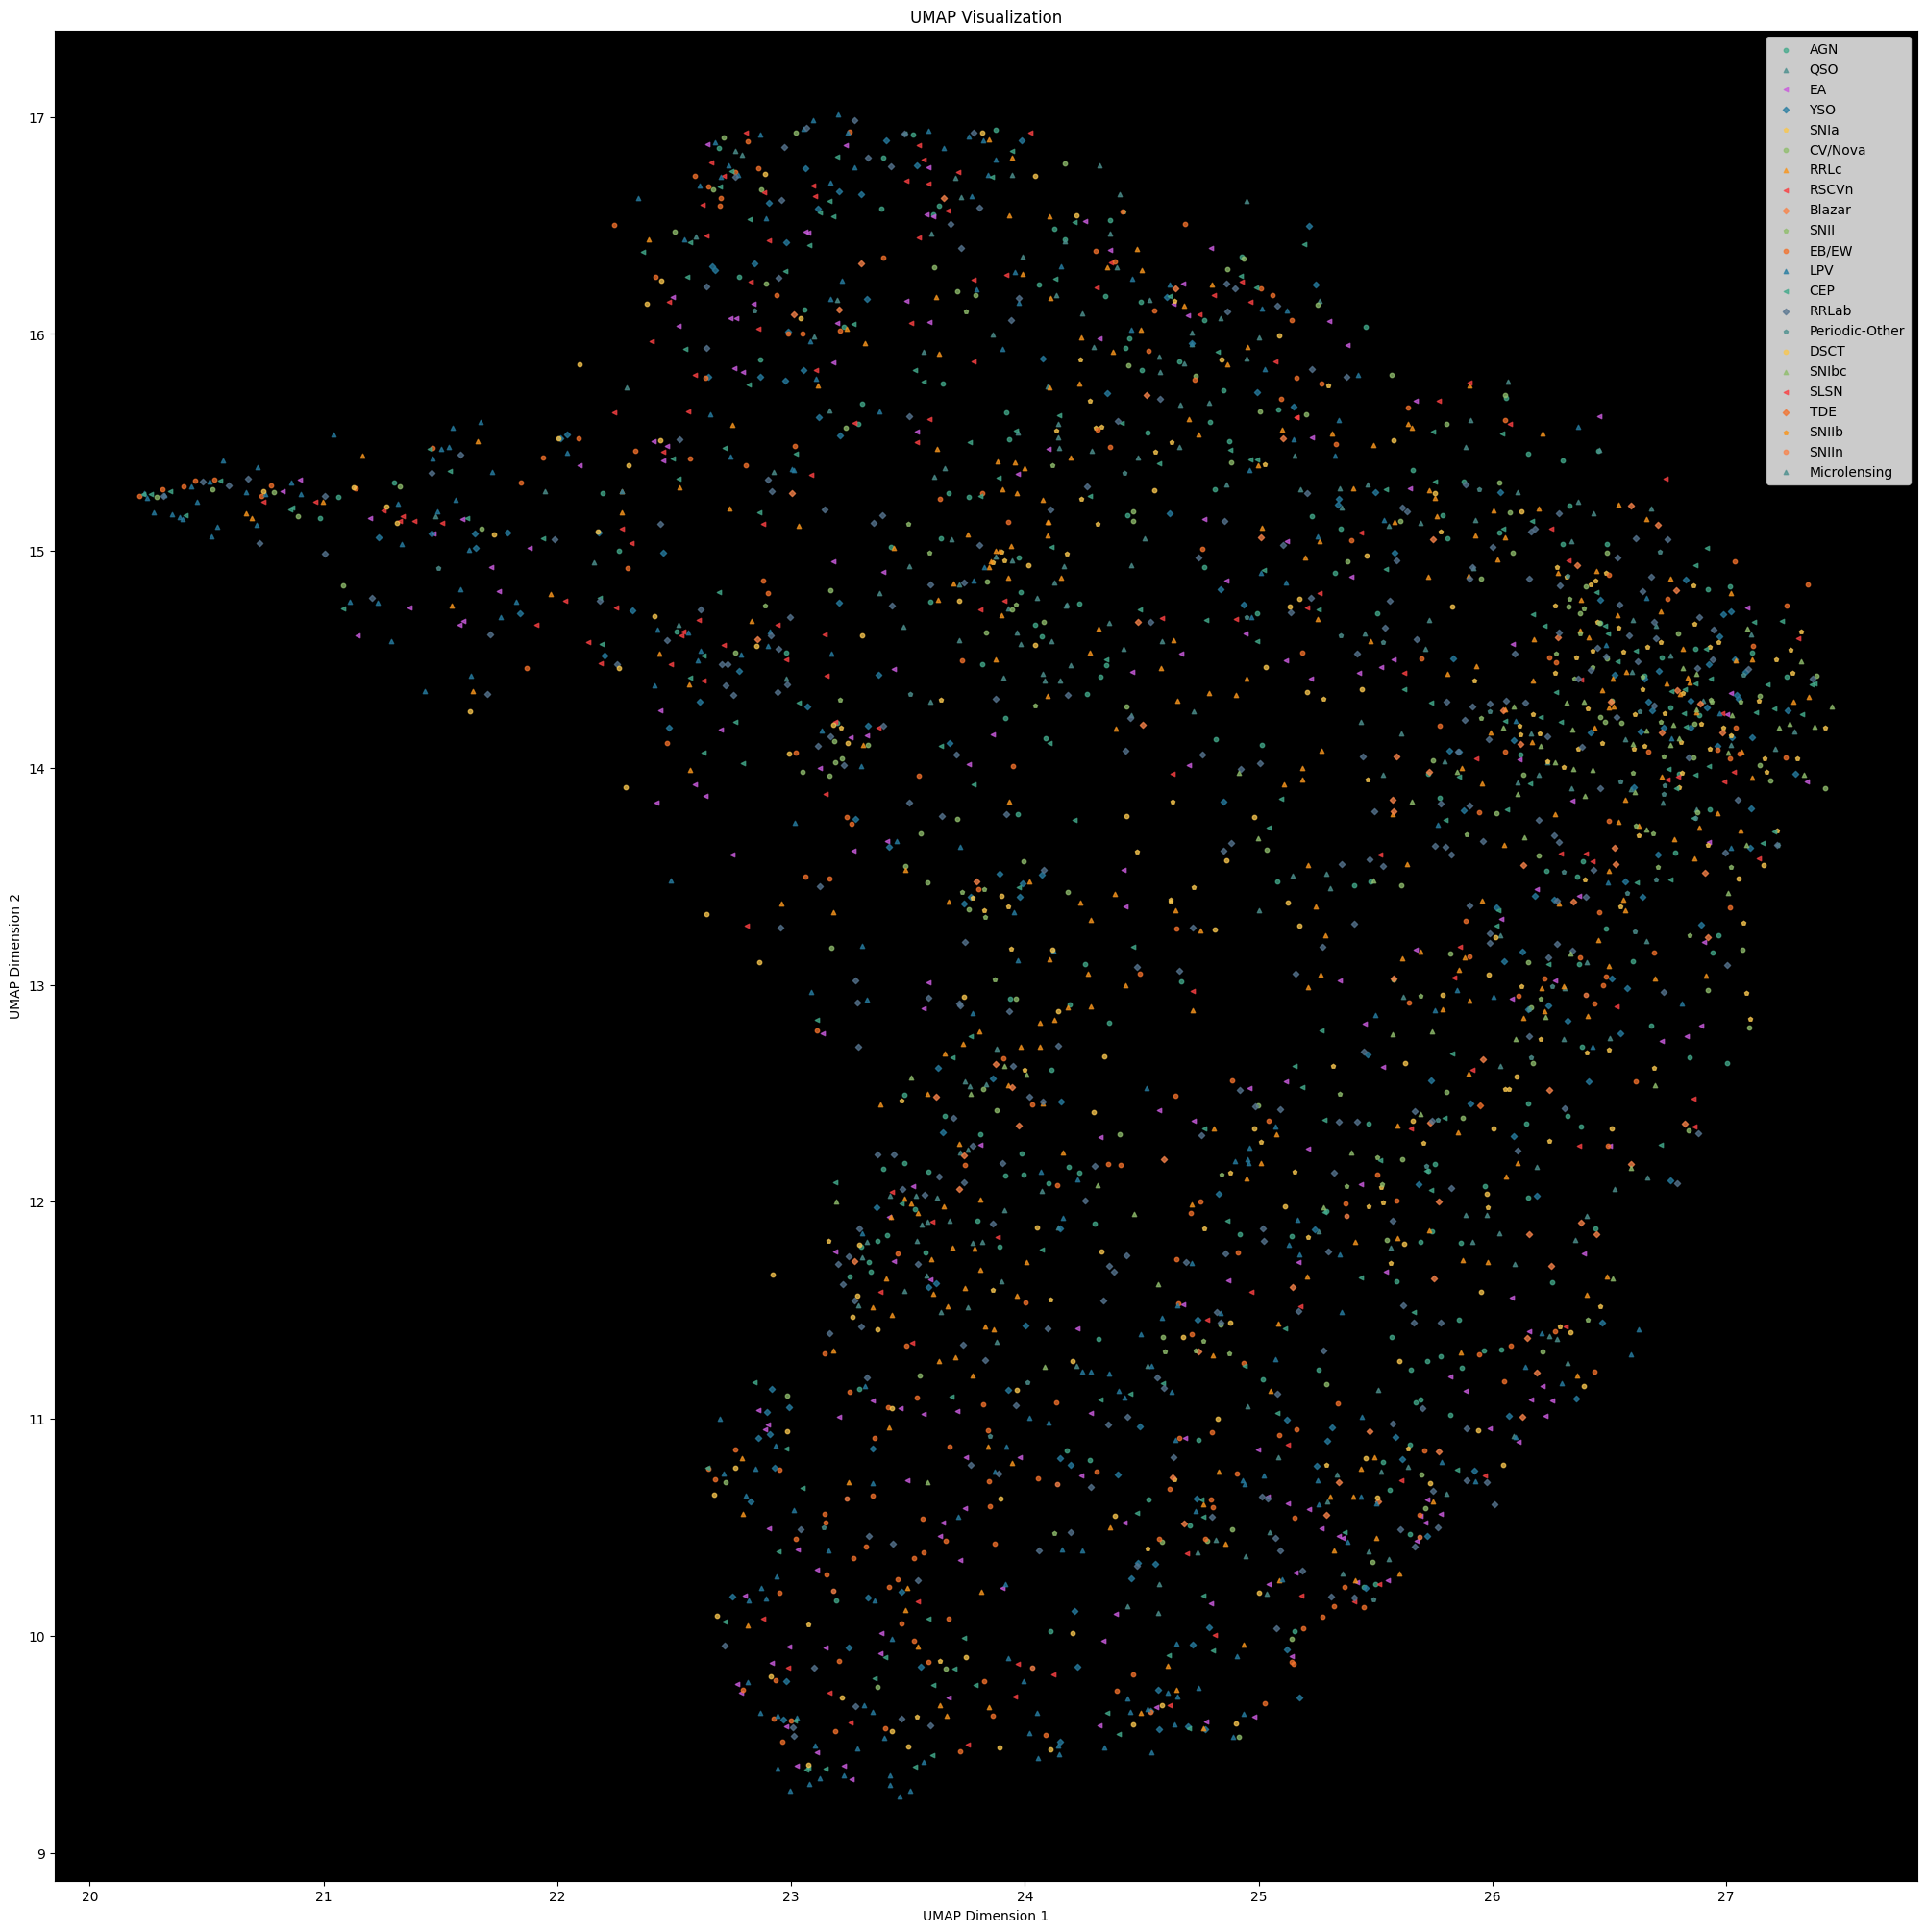

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(25, 25))
plot_umap(axs, umap_result, target, 22,  'UMAP Visualization')

Text(0.5, 1.0, 'class SNII')

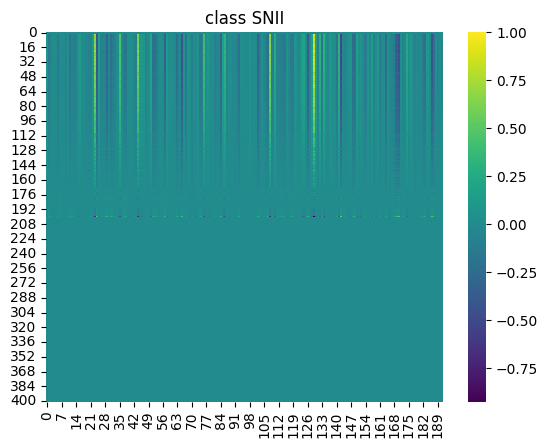

In [16]:
n = 9
sns.heatmap(x_mod_out[n,:,:]/x_mod_out[n,:,:].max(),cmap = 'viridis')
plt.title(f'class {list(dict.keys())[n]}')

#token_mask = ~torch.bmm(m_mod.float(),m_mod.transpose(2,1).float()).bool() 

In [17]:
import seaborn as sns
preds_out = None
attn_scores = None
target = None
model = model.eval().to(device = 'cuda:2')
count = 0
maxx = 100
for b1 in tqdm(dataloader):
    with torch.no_grad():
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        t = b1['labels']
        b1 = {"x": b1['data'], "t": b1['time'], "mask": b1['mask']}
        x_mod, m_mod, _ = model.LC.embedding_light_curve(**b1)
        m_mod =  ~(m_mod.squeeze(-1))
         
        for i in range(2):
            x_mod, attn = model.LC.transformer_lc.layers[i].self_attn.forward(**{"query": x_mod,
                                                                        "key": x_mod,
                                                                        "value": x_mod,
                                                                        "key_padding_mask":m_mod, 
                                                                        'need_weights':True})
        
        attn_scores = (
            np.concatenate([attn_scores, attn.detach().cpu().numpy()])
            if attn_scores is not None
            else attn.cpu().detach().numpy()
        )

        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
        count +=1
        if count > maxx:
            break

 31%|███▏      | 100/318 [02:08<04:41,  1.29s/it]


In [18]:
df_target = pd.DataFrame({'target': target.astype(int)})
class_indexes = pd.DataFrame({'class':range(0,22),'indexes': [df_target[df_target['target'] == i].index.to_list()  for i in range(0,22)]})
class_indexes

,class,indexes
0,0,"[57, 58, 59, 60, 61, 62, 63, 64, 71, 72, 73, 7..."
1,1,"[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
2,2,"[13, 14, 15, 16, 17, 18, 19, 128, 129, 130, 13..."
3,3,"[106, 107, 108, 109, 110, 111, 112, 113, 308, ..."
4,4,"[65, 66, 67, 68, 69, 70, 452, 453, 454, 455, 4..."
5,5,"[239, 240, 241, 242, 243, 244, 245, 246, 247, ..."
6,6,"[8, 9, 10, 11, 12, 78, 79, 80, 81, 82, 83, 84,..."
7,7,"[51, 833, 834, 835, 1271, 1272, 1273, 1274, 13..."
8,8,"[47, 48, 49, 50, 52, 53, 54, 55, 56, 91, 92, 9..."
9,9,"[353, 354, 355, 448, 462, 783, 784, 785, 786, ..."


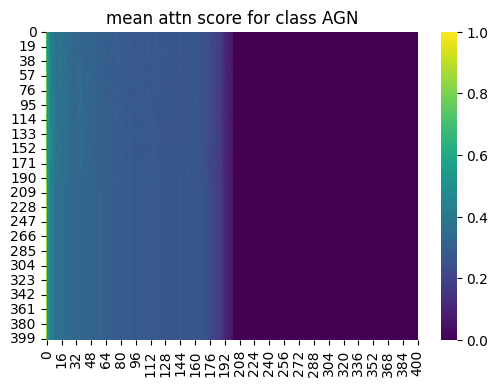

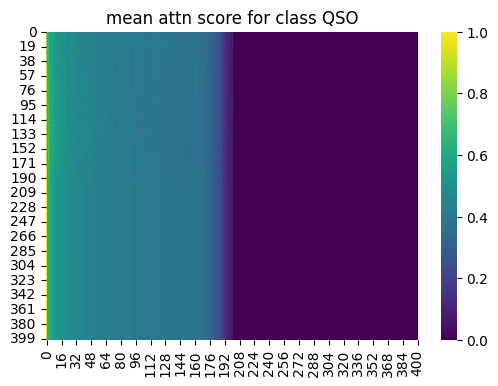

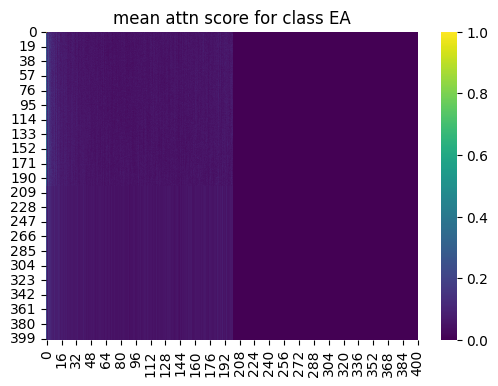

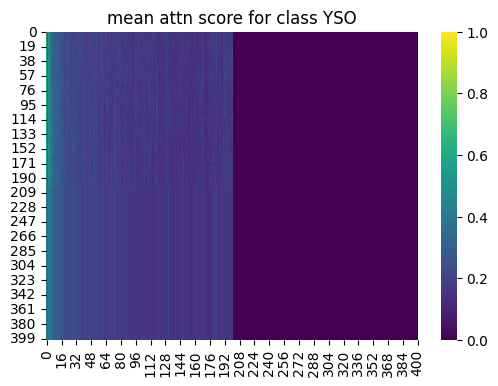

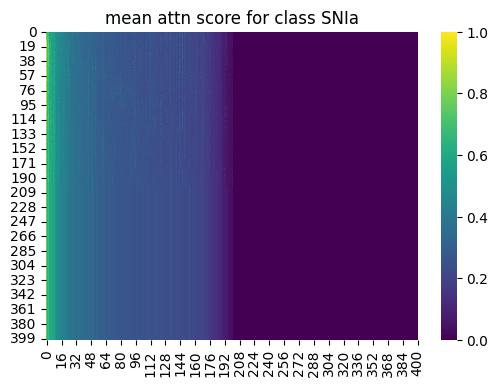

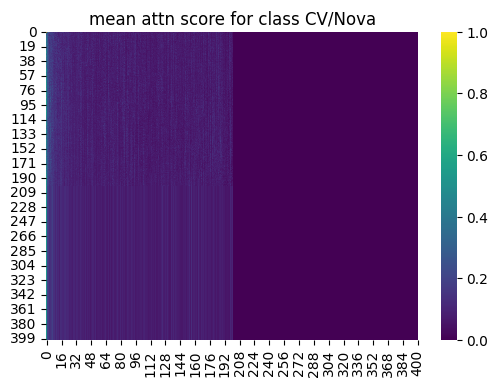

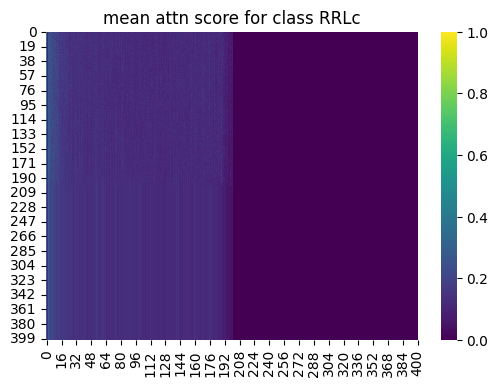

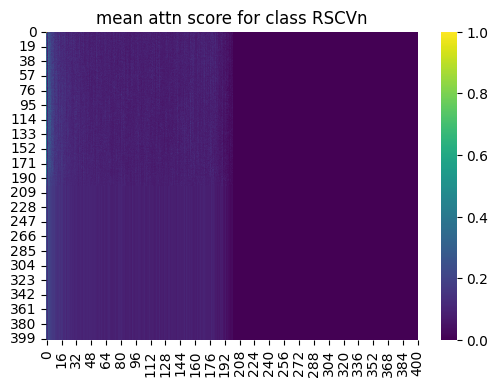

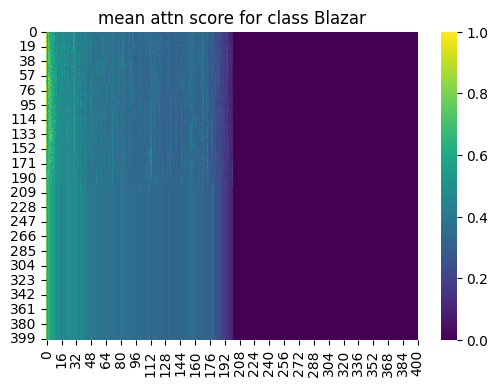

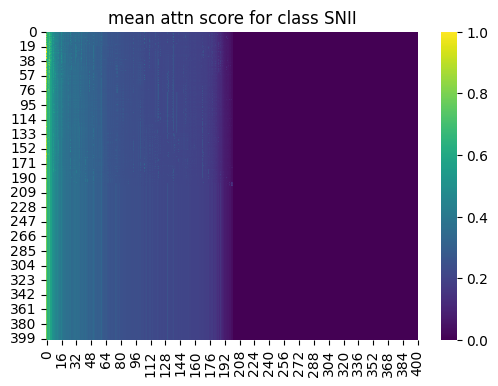

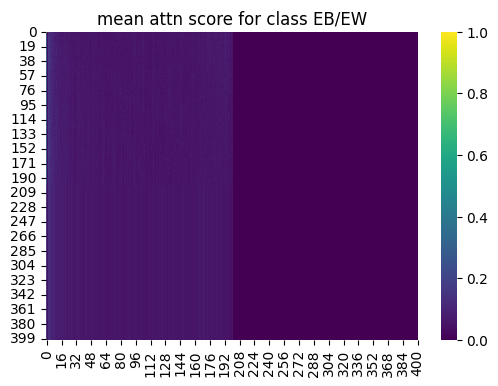

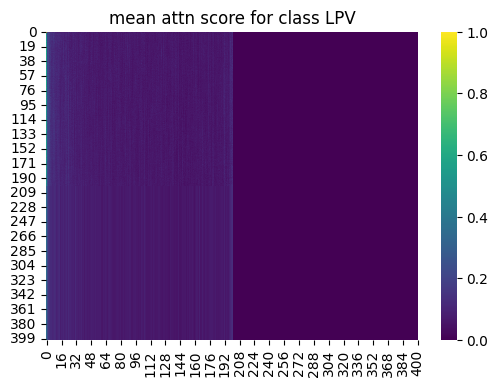

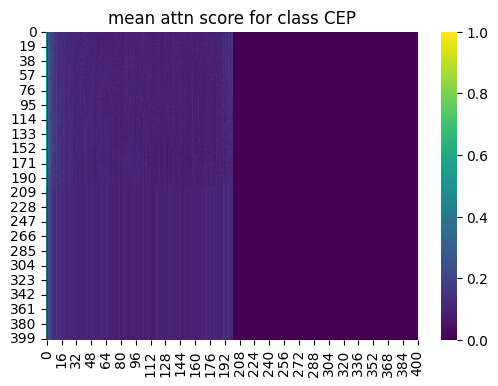

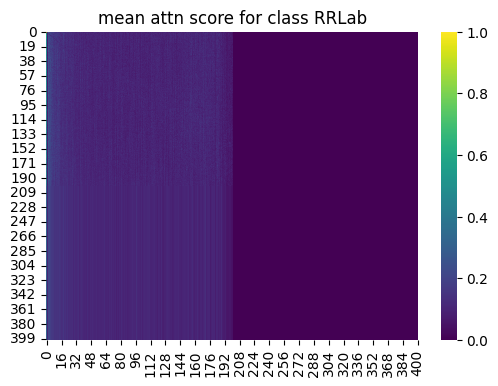

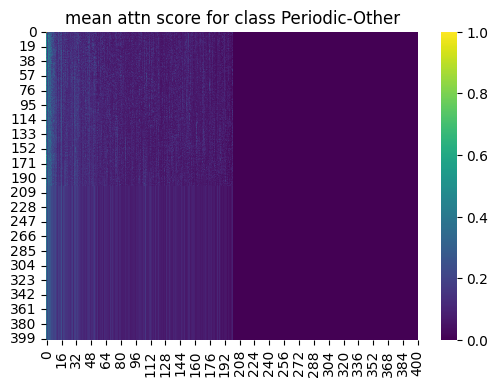

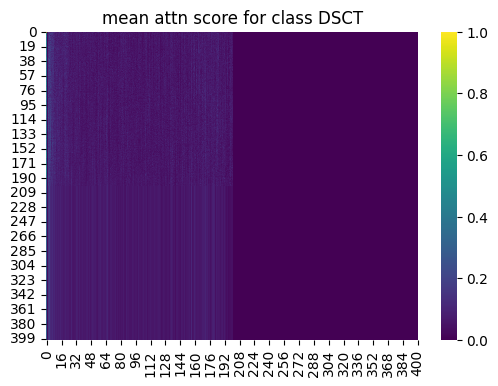

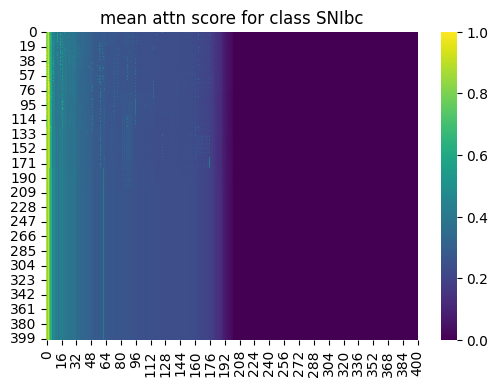

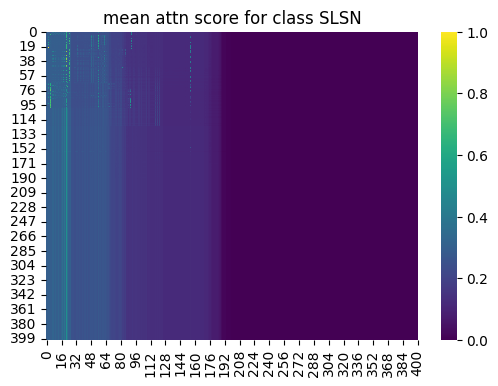

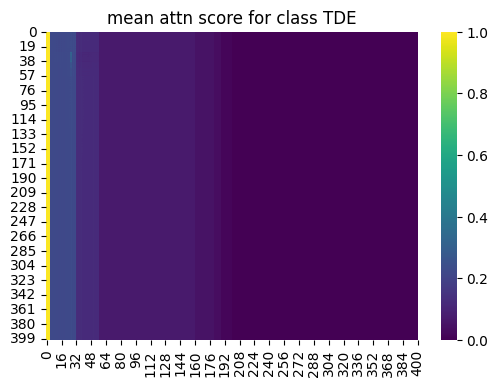

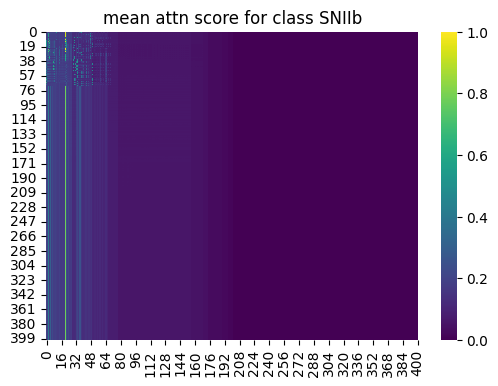

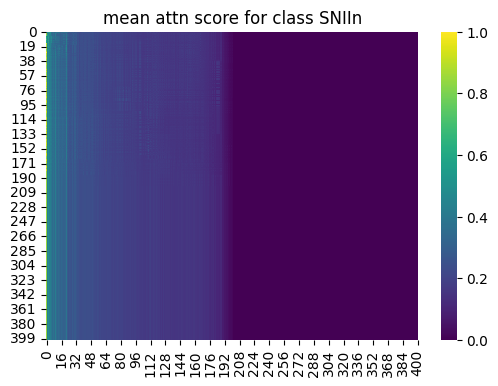

In [19]:
for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    fig,ax = plt.subplots(1,1,figsize = (6,4))
    attn_0 = attn_scores[class_indexes['indexes'].iloc[i]]
    mean_attn_0 = attn_0.mean(axis = 0,keepdims = True)/  attn_0.mean(axis = 0,keepdims = True).max()
    sns.heatmap(mean_attn_0[0,:,:], cmap = 'viridis',ax = ax)
    #sns.heatmap(mean_attn_0[0,:,:]> 0, cmap = 'viridis',ax = ax[1])
    plt.title( f'mean attn score for class {list(dict.keys())[i]}')
    plt.show()
    

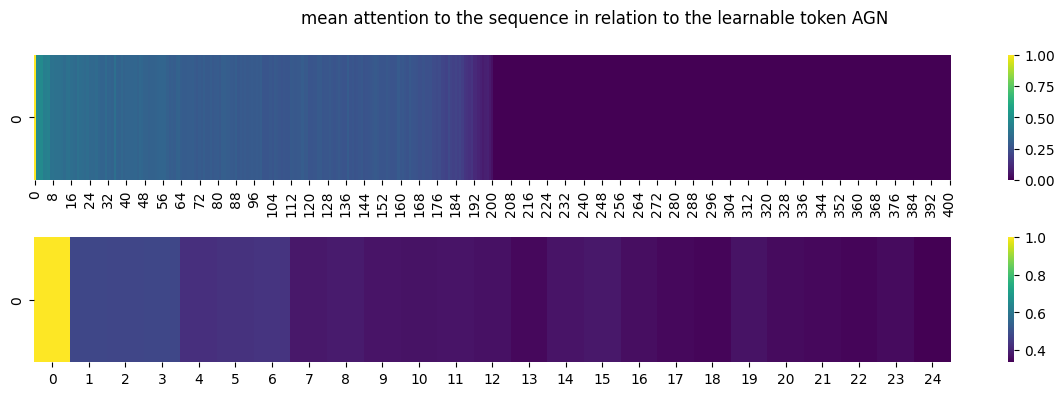

[[1.]]


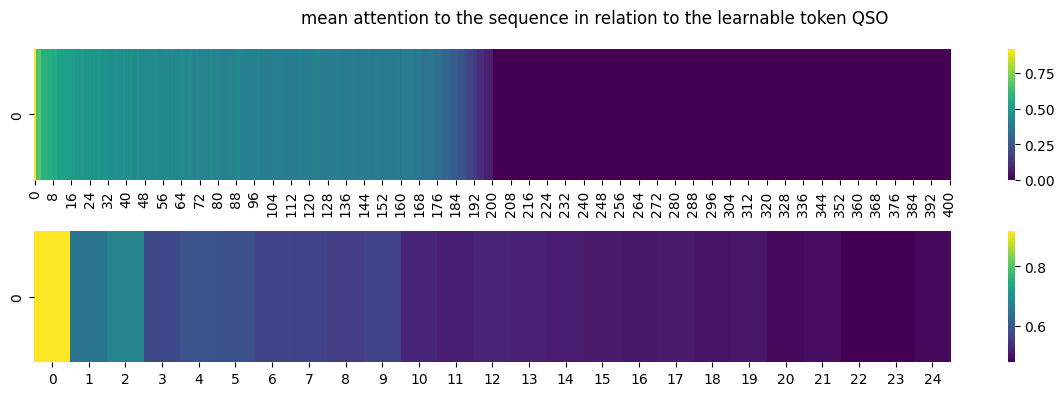

[[0.917662]]


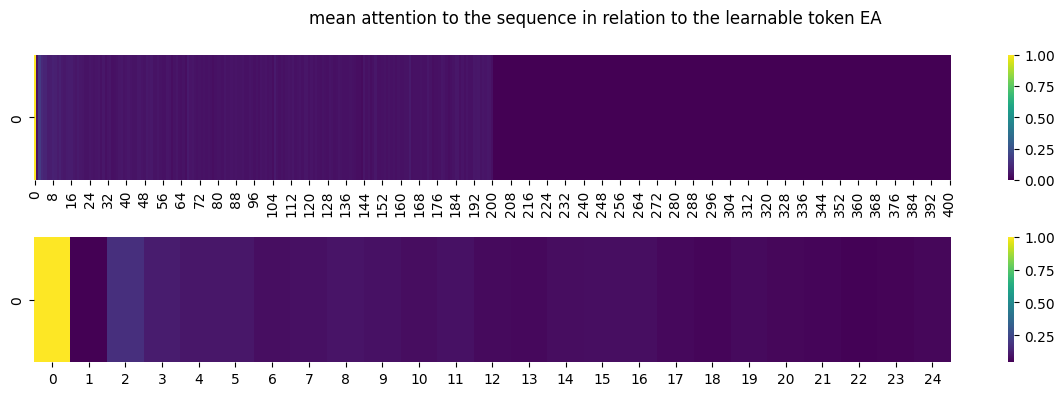

[[1.]]


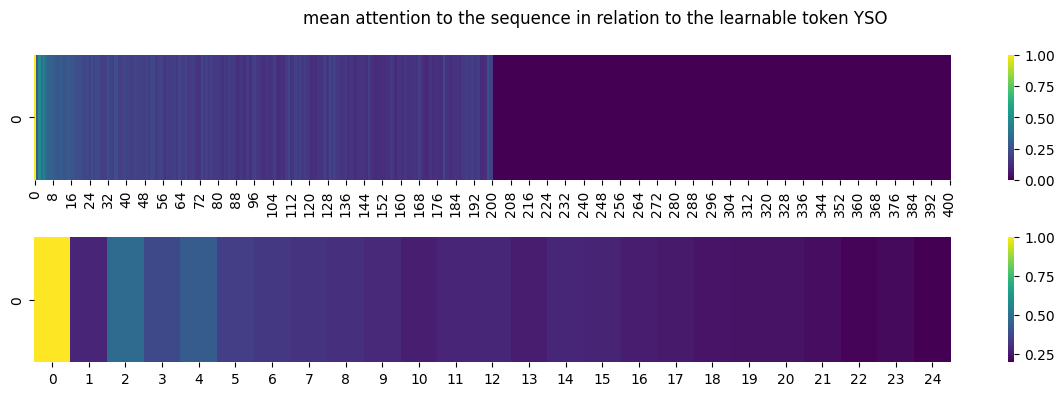

[[1.]]


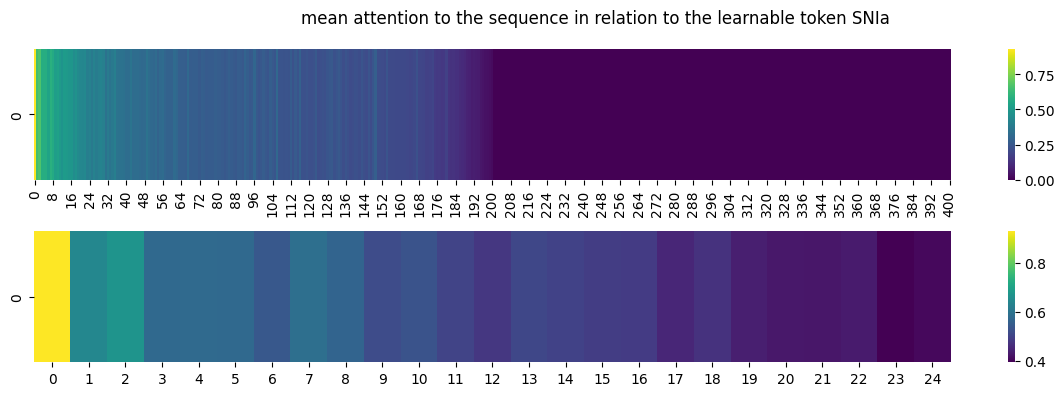

[[0.92803425]]


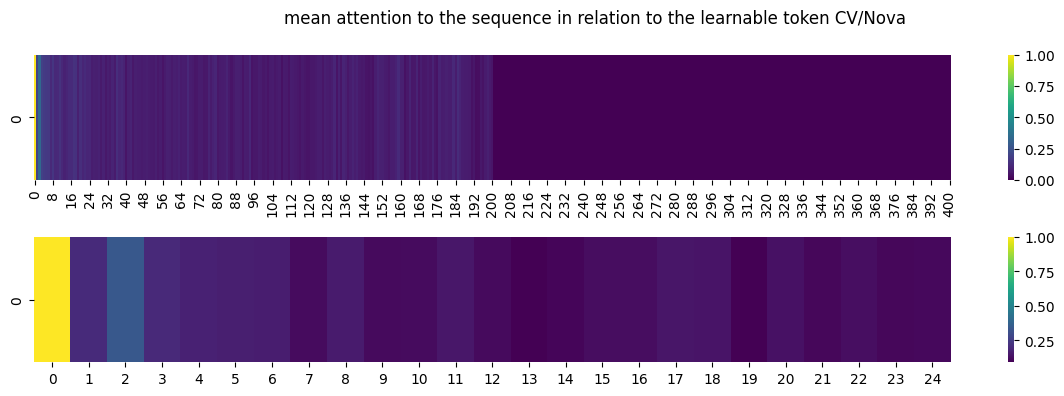

[[1.]]


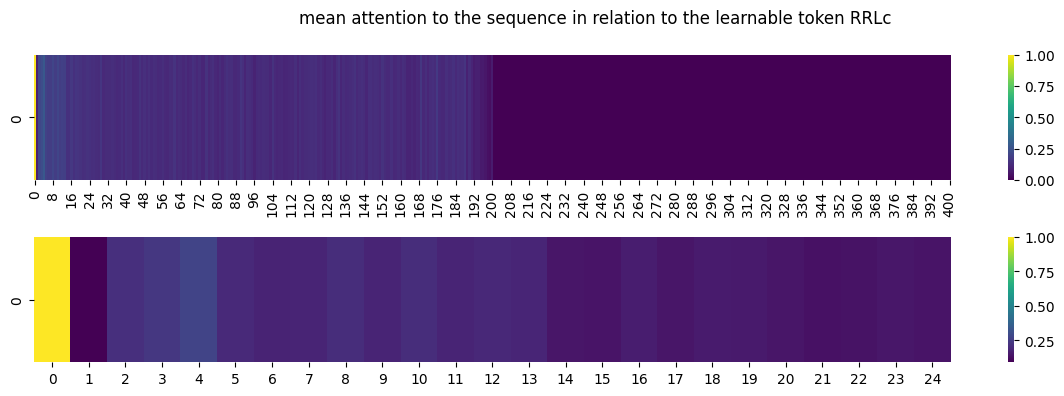

[[1.]]


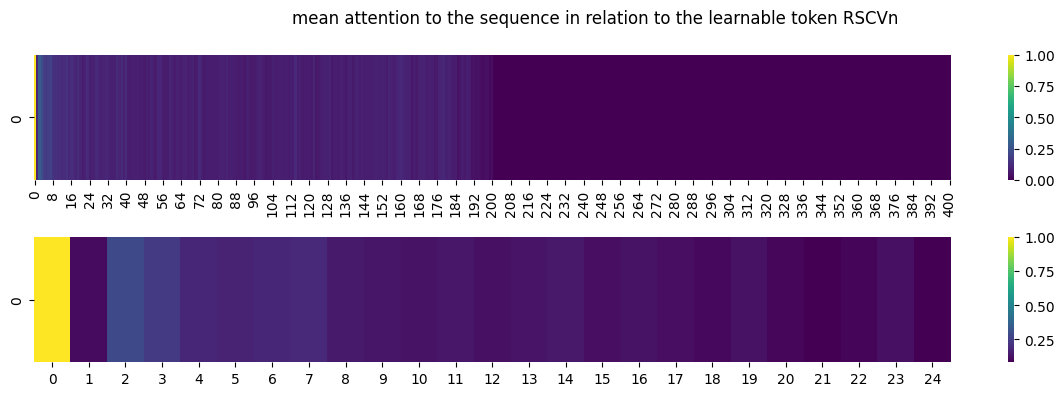

[[1.]]


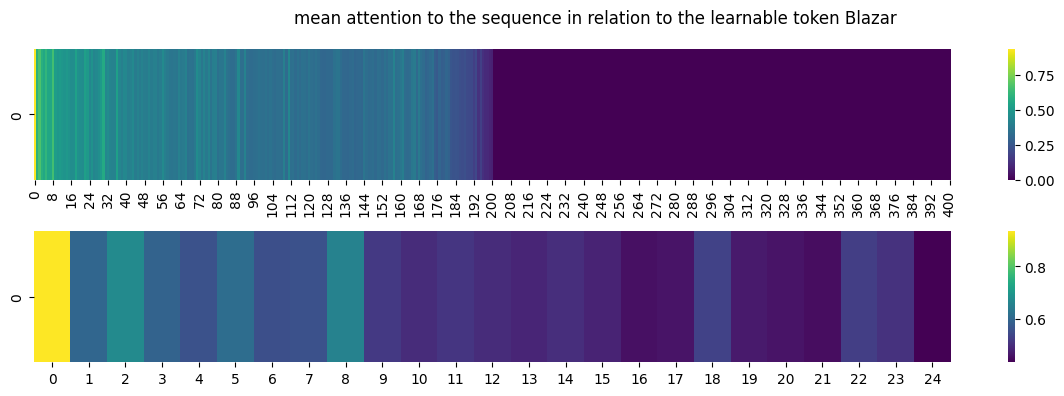

[[0.93490285]]


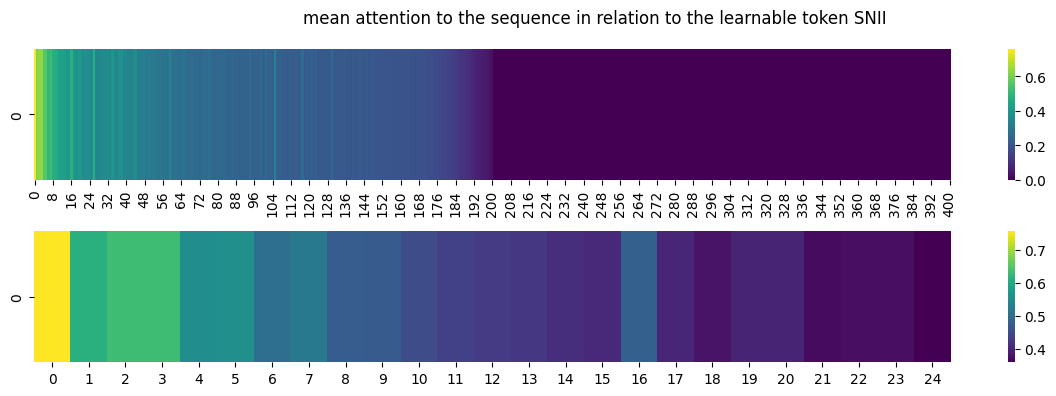

[[0.756557]]


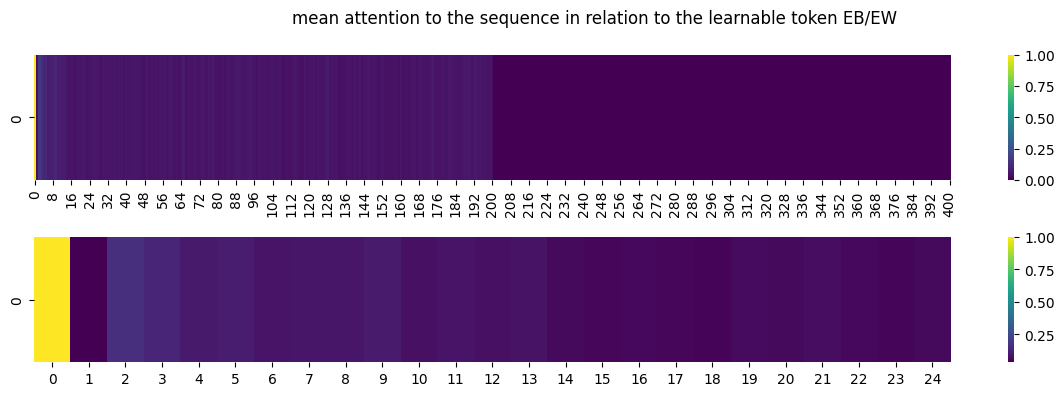

[[1.]]


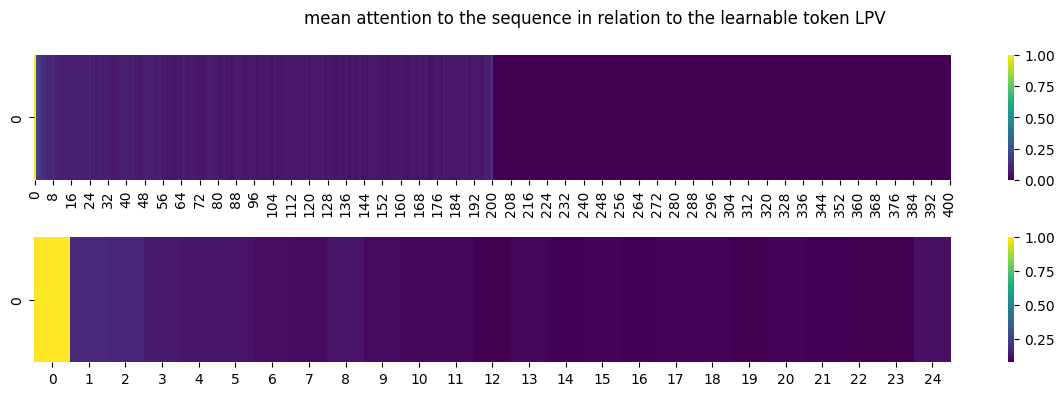

[[1.]]


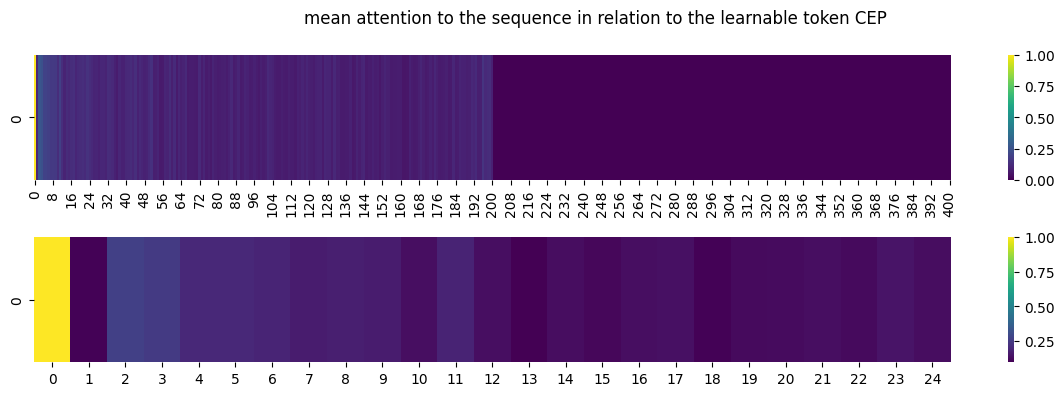

[[1.]]


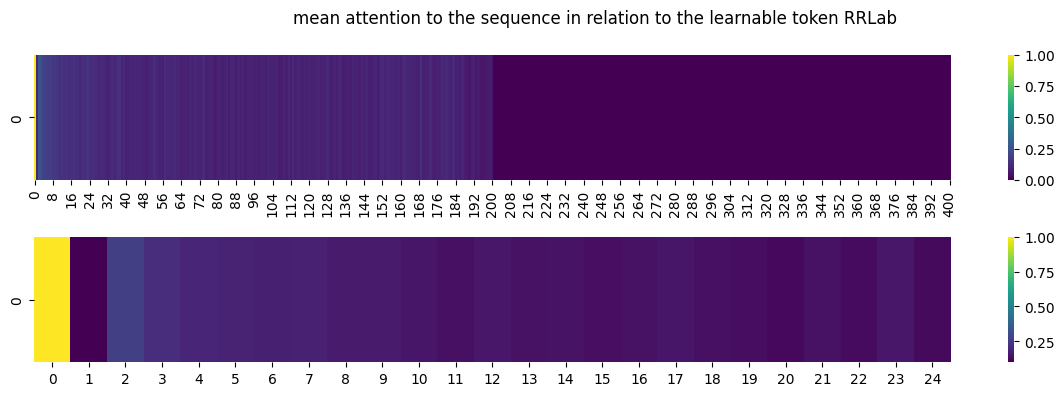

[[1.]]


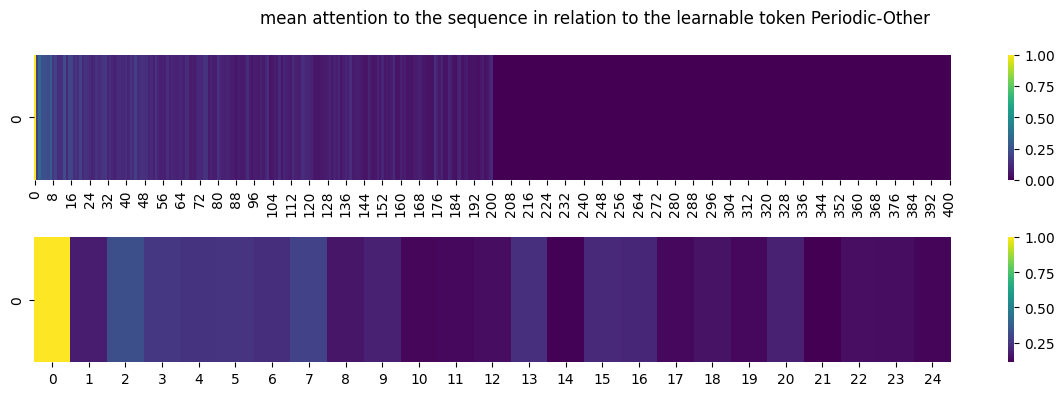

[[1.]]


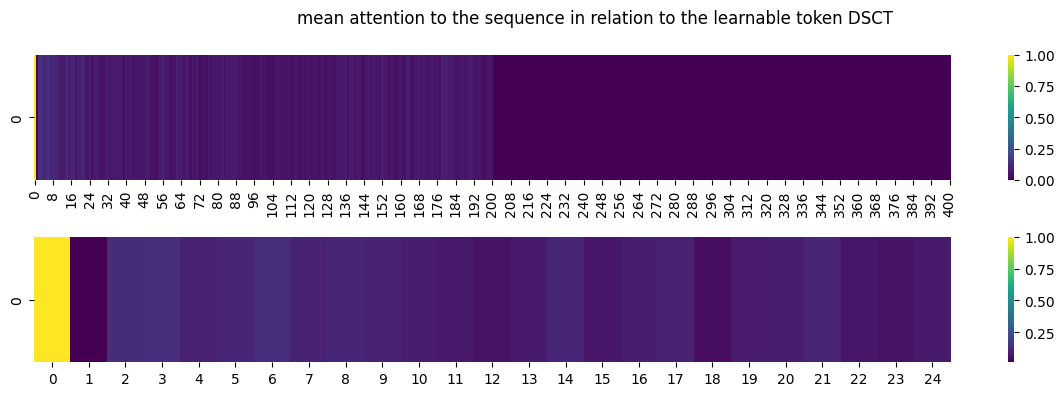

[[1.]]


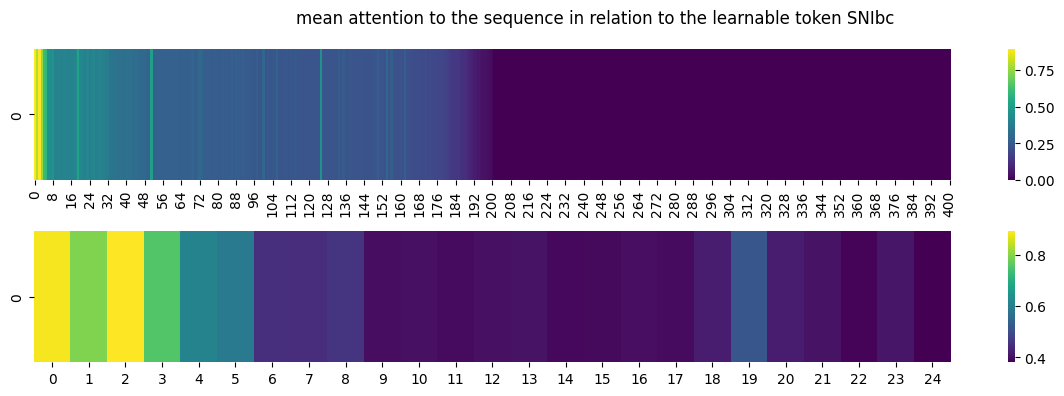

[[0.885506]]


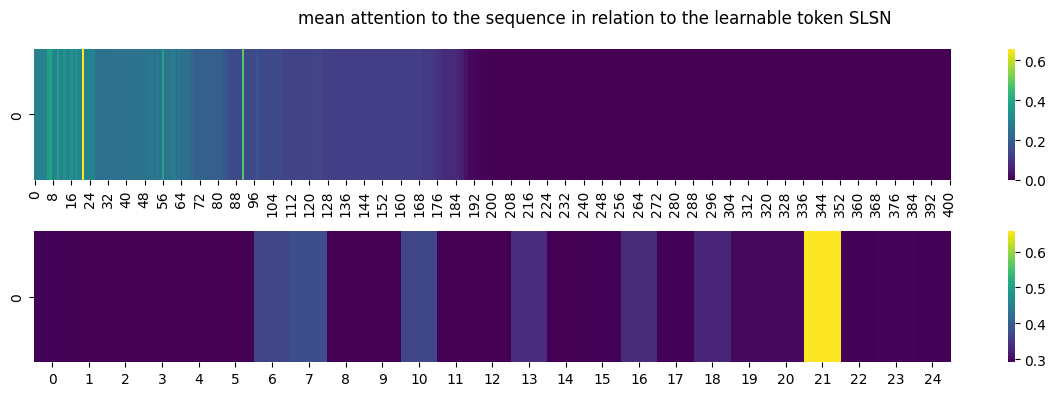

[[0.29318145]]


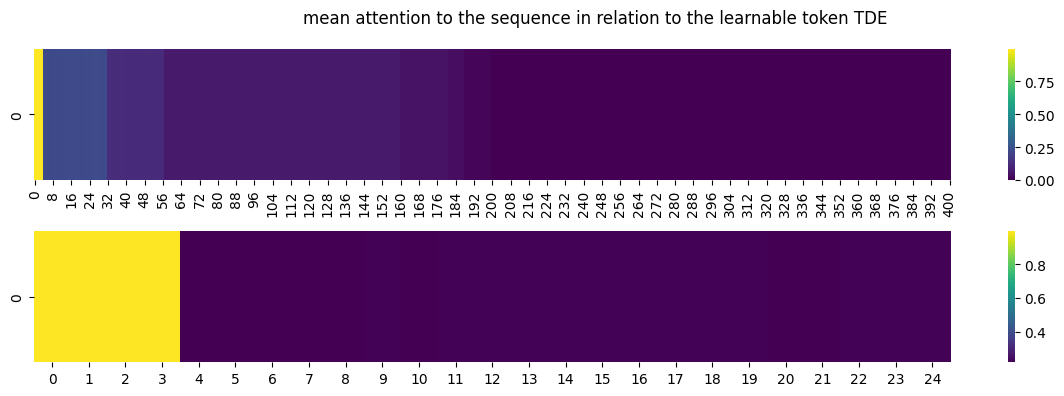

[[0.9924314]]


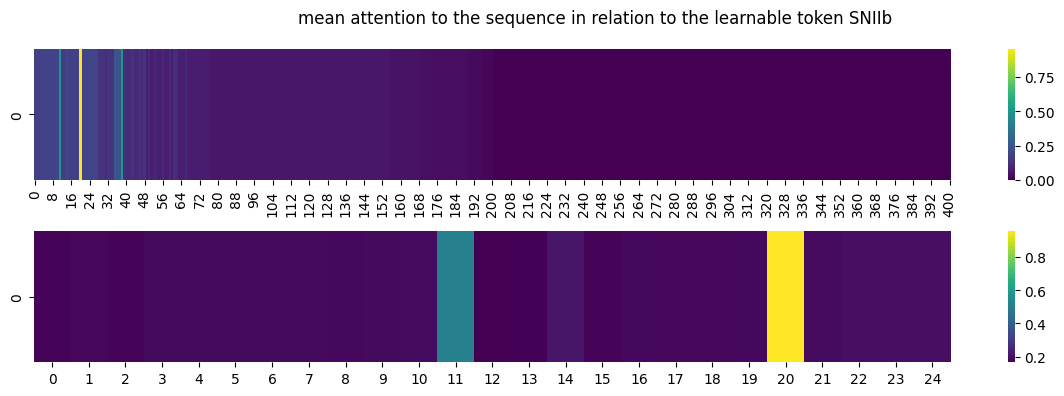

[[0.17517686]]


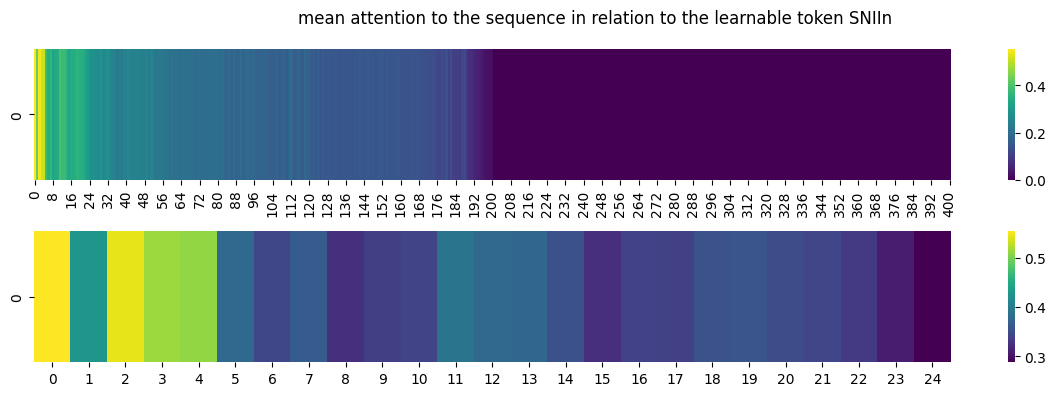

[[0.5542602]]


In [20]:
##what elements or the sequence does the model pay attention to in relation to the learnable token?
for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    fig,ax = plt.subplots(2,1,figsize = (12,4))
    attn_0 = attn_scores[class_indexes['indexes'].iloc[i]]
    mean_attn_0 = attn_0.mean(axis = 0,keepdims = True)/  attn_0.mean(axis = 0,keepdims = True).max()
    sns.heatmap(mean_attn_0[0,:1,:], cmap = 'viridis',ax = ax[0])
    sns.heatmap(mean_attn_0[0,:1,:25], cmap = 'viridis',ax = ax[1])
    
    plt.suptitle( f'mean attention to the sequence in relation to the learnable token {list(dict.keys())[i]}')
    plt.tight_layout()
    plt.show()
    print(mean_attn_0[0,:1,:1])

In [21]:
target = None
preds_out = None

model.eval().to(device = 'cuda:2')  

for b1 in tqdm(dataloader):

    #print(b1.keys())
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}

    lc_emb = model.LC(**b1)[:,0,:]
   
    t = b1['labels']


    preds_out = (
        np.concatenate([preds_out,lc_emb.detach().cpu().numpy()])
        if preds_out is not None
        else lc_emb.cpu().detach().numpy()
    )

    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.detach().cpu().numpy()
    )
    

100%|██████████| 318/318 [00:19<00:00, 16.66it/s]


In [22]:
df_target = pd.DataFrame({'target': target.astype(int)}) 
class_indexes = pd.DataFrame({'class':range(0,22),'indexes': [df_target[df_target['target'] == i].index.to_list()  for i in range(0,22)]})


In [23]:
class_indexes

,class,indexes
0,0,"[57, 58, 59, 60, 61, 62, 63, 64, 71, 72, 73, 7..."
1,1,"[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
2,2,"[13, 14, 15, 16, 17, 18, 19, 128, 129, 130, 13..."
3,3,"[106, 107, 108, 109, 110, 111, 112, 113, 308, ..."
4,4,"[65, 66, 67, 68, 69, 70, 452, 453, 454, 455, 4..."
5,5,"[239, 240, 241, 242, 243, 244, 245, 246, 247, ..."
6,6,"[8, 9, 10, 11, 12, 78, 79, 80, 81, 82, 83, 84,..."
7,7,"[51, 833, 834, 835, 1271, 1272, 1273, 1274, 13..."
8,8,"[47, 48, 49, 50, 52, 53, 54, 55, 56, 91, 92, 9..."
9,9,"[353, 354, 355, 448, 462, 783, 784, 785, 786, ..."


In [24]:
embeddings = None
for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
     
    attn_0 = preds_out[class_indexes['indexes'].iloc[i]]
    #print(attn_0.shape)
    #attn_0 = np.exp(attn_0)/sum(np.exp(attn_0))
    #attn_0 = (attn_0.mean(axis = 0,keepdims = True)/ attn_0.mean(axis = 0,keepdims = True).max())
    #print(attn_0.shape)
    embeddings = (
        np.concatenate([embeddings, attn_0])
        if embeddings is not None
        else attn_0
    )
    
    
    break
embeddings.shape

(3288, 192)

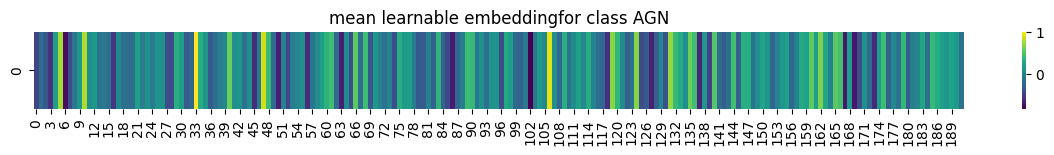

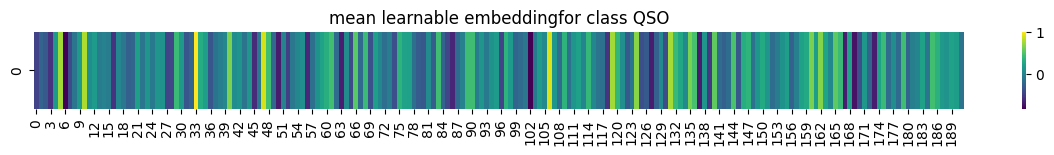

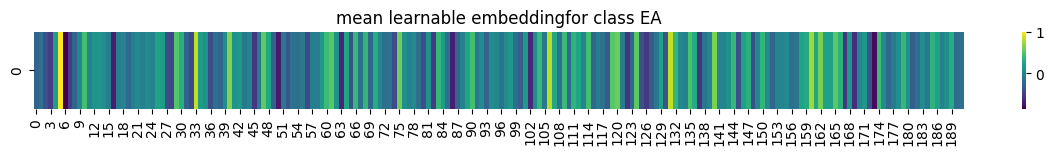

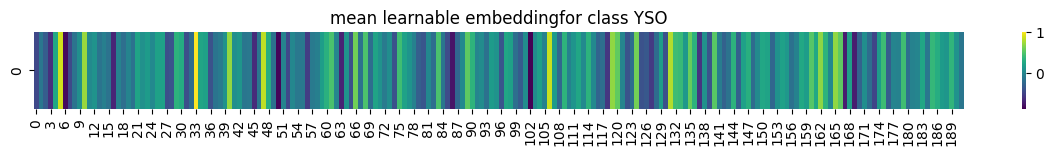

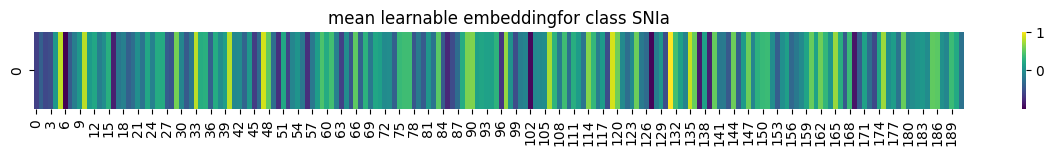

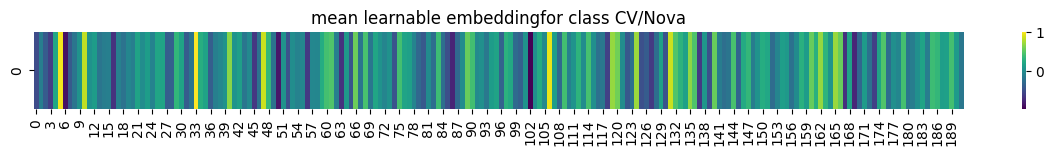

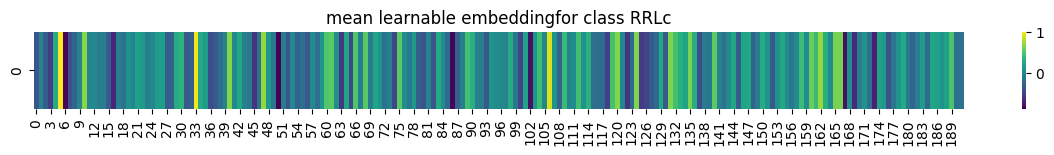

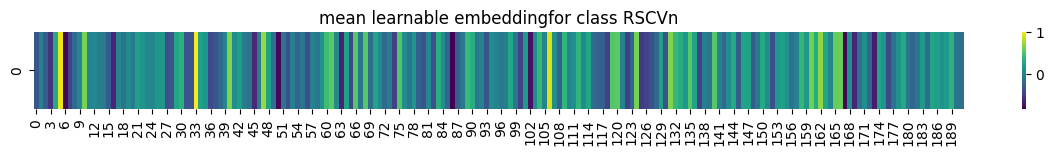

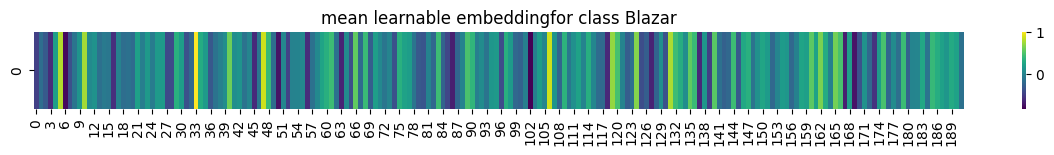

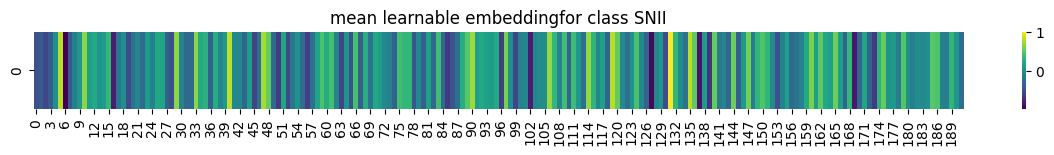

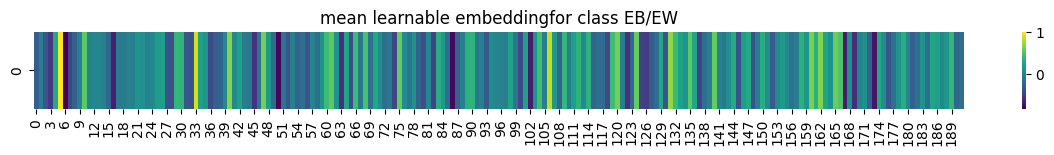

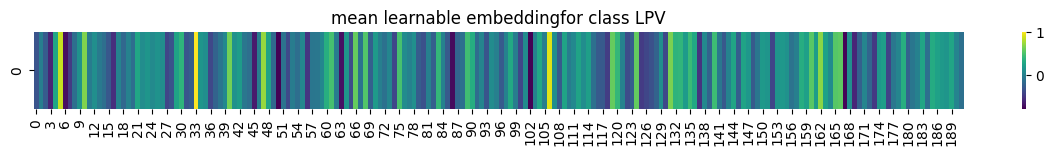

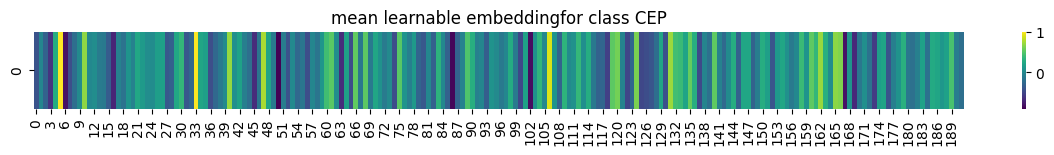

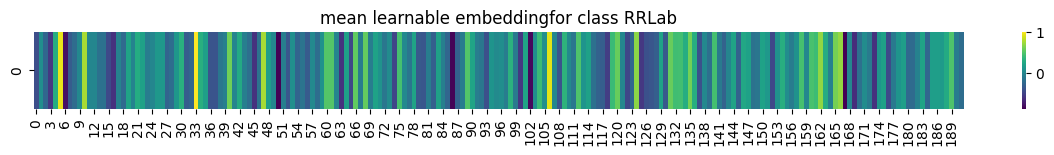

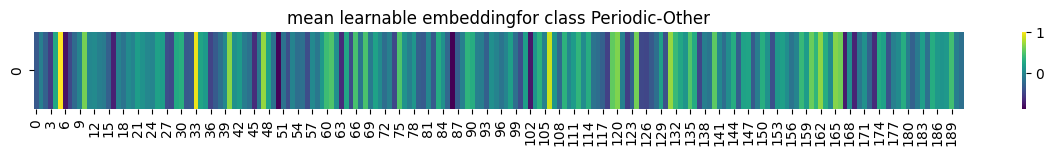

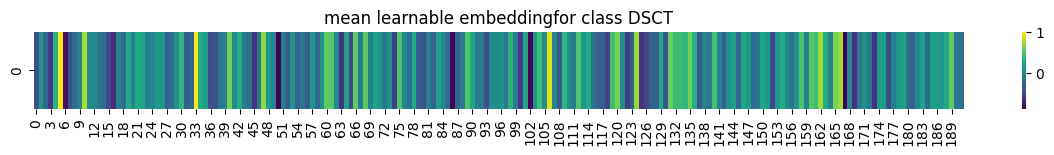

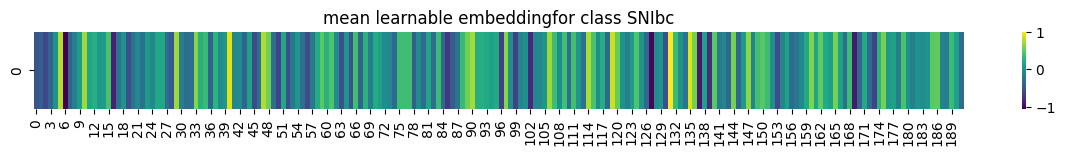

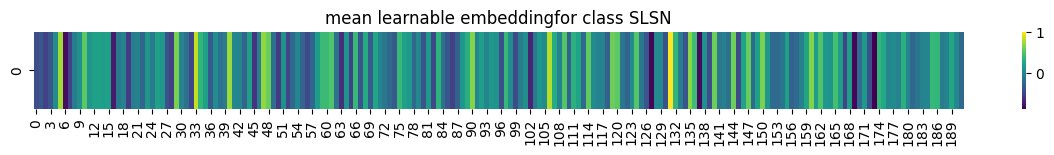

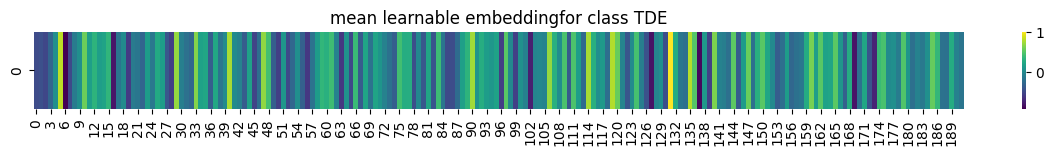

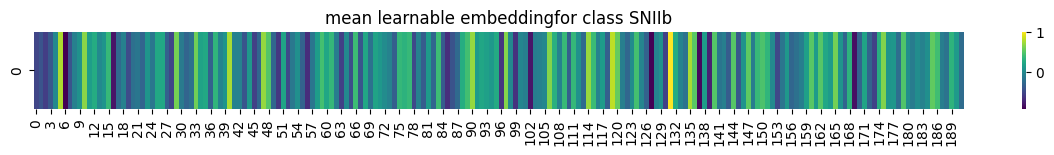

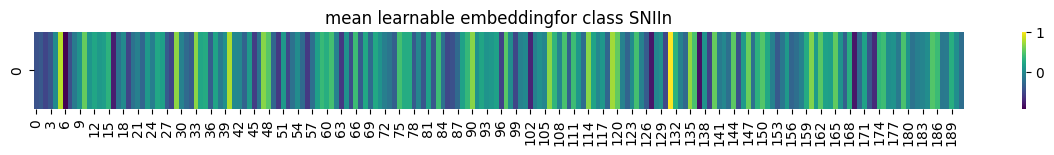

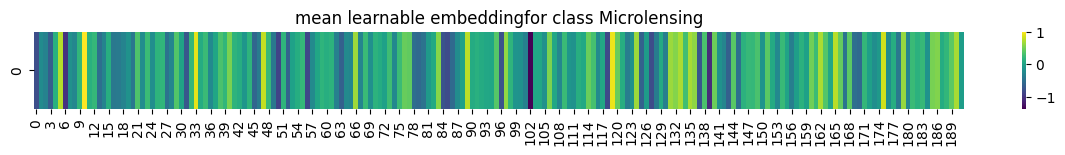

In [25]:

    
embeddings = None
for i in range(22):
    if len(class_indexes['indexes'].iloc[i]) == 0:
        continue
    fig,ax = plt.subplots(1,1,figsize = (15,1))
    attn_0 = preds_out[class_indexes['indexes'].iloc[i]]
    #print(attn_0.shape)
    #attn_0 = np.exp(attn_0)/sum(np.exp(attn_0))
    attn_0 = (attn_0.mean(axis = 0,keepdims = True)/ attn_0.mean(axis = 0,keepdims = True).max())
    #print(attn_0.shape)
    embeddings = (
        np.concatenate([embeddings, attn_0])
        if embeddings is not None
        else attn_0
    )
    
    sns.heatmap(attn_0[:,:], cmap = 'viridis',ax = ax)
    plt.title( f'mean learnable embeddingfor class {list(dict.keys())[i]}')
    plt.show()
    #break

    

(22, 192)


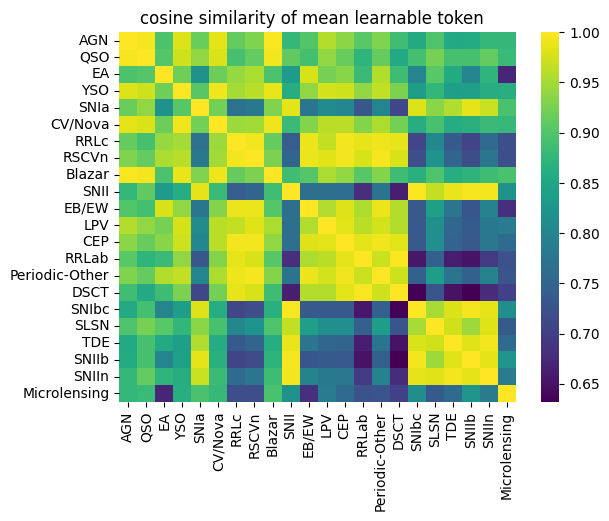

(22, 192)


Text(0.5, 1.0, 'correlation of mean learnable token  ')

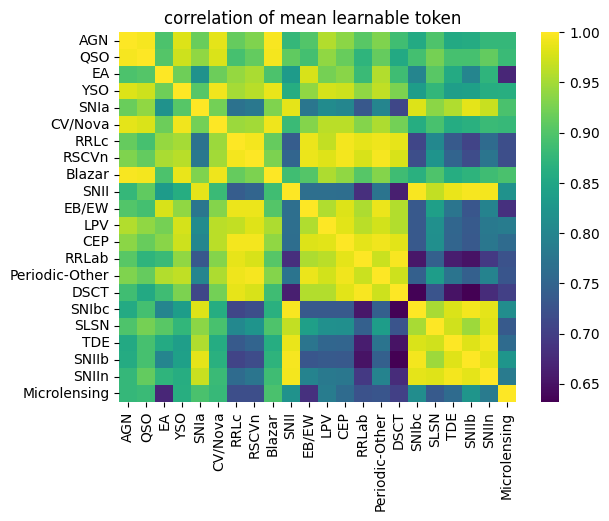

In [26]:
    
def cosine_similarity_1d(embeddings):
        """
        Calculate cosine similarity for a collection of 1D embeddings.
        
        Parameters:
        -----------
        embeddings : numpy.ndarray
            2D array of embeddings where each row is a 1D embedding vector
        
        Returns:
        --------
        similarity_matrix : numpy.ndarray
            Symmetric matrix of cosine similarities between all embeddings
        """
        # Normalize embeddings to unit length
        normalized_embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
         

        # Compute cosine similarity using dot product
        similarity_matrix = np.dot(normalized_embeddings, normalized_embeddings.T) 
        
        return similarity_matrix
similarities = cosine_similarity_1d(embeddings)
print(embeddings.shape)
sns.heatmap(similarities, cmap = 'viridis',xticklabels=list(dict.keys()), yticklabels=list(dict.keys()))
plt.title('cosine similarity of mean learnable token  ')

plt.show()

similarities = np.corrcoef(embeddings)
print(embeddings.shape)
sns.heatmap(similarities, cmap = 'viridis',xticklabels=list(dict.keys()), yticklabels=list(dict.keys()))
plt.title('correlation of mean learnable token  ')

In [27]:
from sklearn.decomposition import PCA

red = PCA()
results = red.fit_transform(preds_out)
red.components_.shape

(192, 192)